# GLCM

In [ ]:
import numpy as np
import cv2
import networkx as nx
from skimage.feature import local_binary_pattern
from google.colab.patches import cv2_imshow
from skimage.feature import graycomatrix, graycoprops
import numpy as np

In [ ]:
# dilate mask and get inner and outer boundary of contour
def get_coord(mask, iterations):

  kernel = np.ones((3,3), np.uint8)

  # find dilated image
  dilated = cv2.dilate(mask, kernel, iterations=iterations)
  # cv2_imshow(dilated)

  # find the boundaries
  eroded= cv2.erode(dilated, kernel, iterations=1)
  final= dilated-eroded
  # cv2_imshow(final)

  contours, hierarchy = cv2.findContours(final.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
  # contours = contours[::-1]
  # hierarchy = hierarchy[::-1]

  # find inner and outer contours
  outer_contours = []
  inner_contours = []

  outer=[]
  inner=[]

  mx=-1
  for i in hierarchy[0]:
    mx= max(mx, i[3])

  for i, contour in enumerate(contours):
    #print(hierarchy[0][i][3])
    # Check the hierarchy to classify contours
    if hierarchy[0][i][3] == -1 and len(outer)==0:  # Outer contour (no parent)
      outer_contours.append(contour)
      for point in contour:
        x, y = point[0]  # Extracting x and y from point
        outer.append([y,x])
    elif hierarchy[0][i][3] == mx:  # Inner contour (has a parent)
      inner_contours.append(contour)
      for point in contour:
        x, y = point[0]  # Extracting x and y from point
        inner.append([y,x])

  # output_image = np.zeros_like(mask)
  # for p in outer:
  #   output_image[p[0],p[1]]=255
  # cv2_imshow(output_image)
  # for p in inner:
  #   output_image[p[0],p[1]]=255
  # cv2_imshow(output_image)

  # find all points which are white
  white = np.column_stack(np.where(dilated == 255)).tolist()

  return white, outer, inner


In [ ]:
def similarity_function(x1,x2,y1,y2,glcm_texture, sigma_I=10, sigma_C=5, sigma_R=5, sigma_d=2):
    """
    Compute similarity weight between two pixels using intensity, contrast, and correlation.

    Parameters:
    - p, q: Pixel intensity (or color vector for RGB).
    - contrast_p, contrast_q: Contrast values of pixels.
    - corr_p, corr_q: Correlation values of pixels.
    - sigma_I, sigma_C, sigma_R, sigma_d: Controls for weighting factors.

    Returns:
    - Similarity weight (0 to 1).
    """
    intensity_diff = np.linalg.norm(np.array(img[x1,y1]) - np.array(img[x2,y2]))
    contrast_diff = np.linalg.norm(np.array(glcm_features["contrast"][x1,y1]) - np.array(glcm_features["contrast"][x2,y2]))
    correlation_diff = np.linalg.norm(np.array(glcm_features["correlation"][x1,y1]) - np.array(glcm_features["correlation"][x2,y2]))
    homogeneity_diff= np.linalg.norm(np.array(glcm_features["homogeneity"][x1,y1]) - np.array(glcm_features["homogeneity"][x2,y2]))
    energy_diff= np.linalg.norm(np.array(glcm_features["energy"][x1,y1]) - np.array(glcm_features["energy"][x2,y2]))
    spatial_diff = 1  # If adjacent, d(p, q) ≈ 1

    return (
        np.exp(- (intensity_diff ** 2) / (2 * sigma_I ** 2)) *
        np.exp(- (contrast_diff ** 2) / (2 * sigma_C ** 2)) *
        #np.exp(- (correlation_diff ** 2) / (2 * sigma_R ** 2)) *
        np.exp(- (spatial_diff ** 2) / (2 * sigma_d ** 2))
    )


# create custom weight function
def get_weight(img, glcm_texture, lst1, lst2, texture_weight=0.5):
    # s=0
    # for p in ["contrast", "correlation"]:
    #   s+= abs(int(glcm_texture[p][lst1[0], lst1[1]]) - int(glcm_texture[p][lst2[0], lst2[1]]))

    # # s+= abs(img[lst1[0], lst1[1]]- img[lst2[0], lst2[1]])
    # # Combine intensity and scaled texture difference
    # weight = 1/(1 + s)

    weight= similarity_function(lst1[0], lst2[0],lst1[1],lst2[1],glcm_texture)

    return weight


def get_graph(node_map, glcm_texture):
  G = nx.Graph()

  # Define 8-connectivity for neighboring pixels
  for x in range(height):
    for y in range(width):

      if node_map.get(str([x,y])) == None:
        continue

      if x < height - 1: # down node
        next= [x+1,y]
        b= (node_map.get(str(next)) == None) or (node_map[str([x,y])] == "source" and node_map[str(next)] == "source") or (node_map[str([x,y])] == "sink" and node_map[str(next)] == "sink")
        if b == False:
          weight = get_weight(img,glcm_texture ,[x,y], next)
          G.add_edge(node_map[str([x,y])], node_map[str(next)], capacity= weight)

      if y < width - 1: # right node
        next= [x,y+1]
        b= (node_map.get(str(next)) == None) or (node_map[str([x,y])] == "source" and node_map[str(next)] == "source") or (node_map[str([x,y])] == "sink" and node_map[str(next)] == "sink")
        if b == False:
          weight = get_weight(img,glcm_texture, [x,y], next)
          G.add_edge(node_map[str([x,y])], node_map[str(next)], capacity= weight)


      if x < height - 1 and y < width -1 : # down-right node
        next= [x+1,y+1]
        b= (node_map.get(str(next)) == None) or (node_map[str([x,y])] == "source" and node_map[str(next)] == "source") or (node_map[str([x,y])] == "sink" and node_map[str(next)] == "sink")
        if b == False:
          weight = get_weight(img,glcm_texture, [x,y], next)
          G.add_edge(node_map[str([x,y])], node_map[str(next)], capacity= weight)


      if x > 0 and y < width-1: # top-right node
        next= [x-1,y+1]
        b= (node_map.get(str(next)) == None) or (node_map[str([x,y])] == "source" and node_map[str(next)] == "source") or (node_map[str([x,y])] == "sink" and node_map[str(next)] == "sink")
        if b == False:
          weight = get_weight(img,glcm_texture, [x,y], next)
          G.add_edge(node_map[str([x,y])], node_map[str(next)], capacity= weight)

# See graph adjacency list
# G.adj
  return G


In [ ]:
def get_cut(G):
  cut_value, partition = nx.minimum_cut(G, "source", "sink")
  reachable, non_reachable = partition
  cutset = set()
  for u, nbrs in ((n, G[n]) for n in reachable):
    cutset.update((u, v) for v in nbrs if v in non_reachable)

  return cutset


In [ ]:
def nearest_source(a, node_map):
  dx= [-1, -1, -1, 0, 0, 1, 1, 1]
  dy= [-1, 0, 1, -1, 1, -1, 0, 1]
  for k in range(8):
    x= a[0]+ dx[k]
    y= a[1]+ dy[k]
    if node_map.get(str([x,y])) != None and node_map[str([x,y])]=="source":
      return (x,y)

  return None

def get_nextmask(cutset, node_map):
  contour_image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
  next_mask = np.zeros_like(img)

  for [a,b] in cutset:
    if a == "source":
      x,y= nearest_source(b, node_map)
      next_mask[x,y]=255
      contour_image[x,y]= (0, 255, 0)
    else:
      next_mask[a[0], a[1]]=255
      contour_image[a[0],a[1]]= (0, 255, 0)

  return next_mask,contour_image


180 200


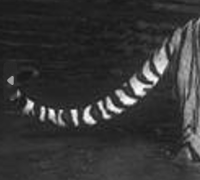

In [ ]:
# Load the image
img = cv2.imread('/content/tail.png', 0)  #load image in grayscale
img= cv2.resize(img, (200, 180))
(height,width)= img.shape
print(height, width)
cv2_imshow(img)


In [ ]:
def get_scaled(mat):
  min_val = np.min(mat)
  max_val = np.max(mat)
  scaled_matrix = ((mat - min_val) / (max_val - min_val)) * 255
  return scaled_matrix

def get_glcm(img, angles, distance):
  # Parameters
  window_size = 7
  levels = 256  # Number of gray levels in the image
  # Padding the image to handle borders
  pad_size = window_size // 2
  padded_image = np.pad(img, pad_width=pad_size, mode='reflect')

  # Initialize matrices for statistical measures
  contrast_matrix = np.zeros_like(img, dtype=float)
  energy_matrix = np.zeros_like(img, dtype=float)
  homogeneity_matrix = np.zeros_like(img, dtype=float)
  correlation_matrix = np.zeros_like(img, dtype=float)

  # Sliding window computation
  for i in range(contrast_matrix.shape[0]):
      if i%10==0:
        print(i)
      for j in range(contrast_matrix.shape[1]):
          # Extract the 7x7 window
          window = padded_image[i:i+window_size, j:j+window_size]

          # Compute the GLCM for the window across all directions
          glcm = graycomatrix(window, distances=distance, angles=angles, levels=levels, symmetric=True, normed=True)

          # Compute statistical measures and average across directions
          contrast = graycoprops(glcm, 'contrast').mean()
          energy = graycoprops(glcm, 'energy').mean()
          homogeneity = graycoprops(glcm, 'homogeneity').mean()
          correlation = graycoprops(glcm, 'correlation').mean()

          # Store the averaged values in their respective matrices
          contrast_matrix[i, j] = contrast
          energy_matrix[i, j] = energy
          homogeneity_matrix[i, j] = homogeneity
          correlation_matrix[i, j] = correlation

  glcm_features= {
      "contrast": get_scaled(contrast_matrix),
      "energy": get_scaled(energy_matrix),
      "homogeneity": get_scaled(homogeneity_matrix),
      "correlation": get_scaled(correlation_matrix)
  }
  return glcm_features


In [ ]:
distance = [5]
angles = [0, np.pi / 2]  # 0°, 45°, 90°, 135° in radians
glcm_features= get_glcm(img, angles, distance)
cv2.imwrite("contrast.png", glcm_features["contrast"])
cv2.imwrite("energy.png", glcm_features["energy"])
cv2.imwrite("homogeneity.png", glcm_features["homogeneity"])
cv2.imwrite("correlation.png", glcm_features["correlation"])

0


KeyboardInterrupt: 

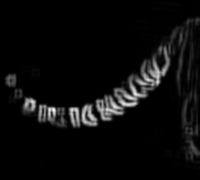

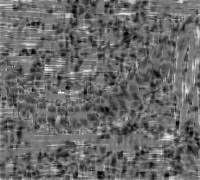

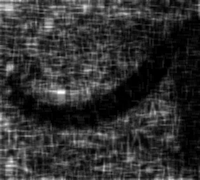

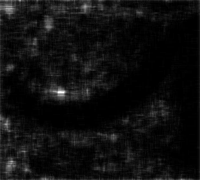

In [ ]:
cv2_imshow(glcm_features["contrast"])
cv2_imshow(glcm_features["correlation"])
cv2_imshow(glcm_features["homogeneity"])
cv2_imshow(glcm_features["energy"])

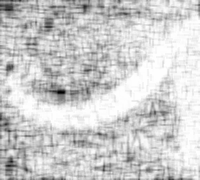

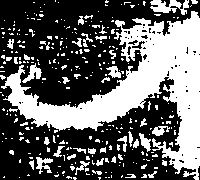

In [ ]:
homo= 255-glcm_features["homogeneity"]
cv2_imshow(homo)
_, binary_thresh = cv2.threshold(homo,220, 255, cv2.THRESH_BINARY)
cv2_imshow(binary_thresh)

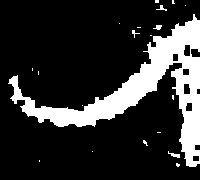

In [ ]:
kernel = np.ones((3,3), np.uint8)  # 5x5 square kernel
erode = cv2.erode(binary_thresh, kernel, iterations=2)
cv2_imshow(erode)

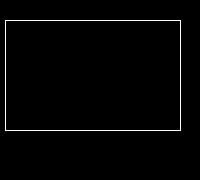

In [ ]:
5# Initial binary mask (user-provided or from an edge detector)
mask = np.zeros_like(img)
#mushroom - cv2.circle(mask,(width//2, height//2),60, 255, 1)
mask= cv2.rectangle(mask, (5,20), (180,130), 255, 1)
cv2_imshow(mask)

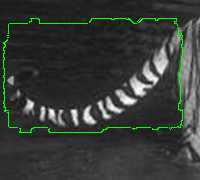

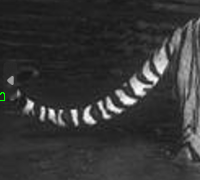

NetworkXError: node source not in graph

In [ ]:
for i in range(100):
  allnodes,sink,source= get_coord(mask, 3)
  node_map={}
  for node in allnodes:
    node_map[str(node)]= (node[0], node[1])

  for node in source:
    node_map[str(node)]= "source"

  for node in sink:
    node_map[str(node)]= "sink"

  G= get_graph(node_map, glcm_features)
  cutset= get_cut(G)
  mask,contour_image= get_nextmask(cutset, node_map)
  cv2_imshow(contour_image)

cv2.waitKey(0)
cv2.destroyAllWindows()

# Local Binary Pattern

Image dimensions: 200 280


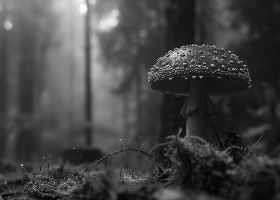

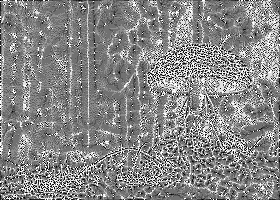

In [ ]:
import numpy as np
import cv2
import networkx as nx
from skimage.feature import local_binary_pattern
from google.colab.patches import cv2_imshow

# Load the image
img = cv2.imread('/content/mushroom.jpeg', 0)  # Load image in grayscale
img = cv2.resize(img, (280, 200))

height, width = img.shape
print("Image dimensions:", height, width)
cv2_imshow(img)

# Parameters for LBP
radius = 1
n_points = 8 * radius

# Compute LBP texture map
lbp_texture = local_binary_pattern(img, n_points, radius, method="uniform")
lbp_texture = (lbp_texture / lbp_texture.max()) * 255  # Normalize to 0-255
lbp_texture = lbp_texture.astype(np.uint8)
cv2_imshow(lbp_texture)


In [ ]:
# Dilate mask and get inner and outer boundaries of contours
def get_coord(mask, iterations):
    kernel = np.ones((3, 3), np.uint8)

    # Find dilated image
    dilated = cv2.dilate(mask, kernel, iterations=iterations)

    # Find the boundaries
    eroded = cv2.erode(dilated, kernel, iterations=1)
    final = dilated - eroded

    contours, hierarchy = cv2.findContours(final.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

    # Find inner and outer contours
    outer = []
    inner = []

    mx = -1
    for i in hierarchy[0]:
        mx = max(mx, i[3])

    for i, contour in enumerate(contours):
        if hierarchy[0][i][3] == -1 and not outer:  # Outer contour (no parent)
            for point in contour:
                x, y = point[0]
                outer.append([y, x])
        elif hierarchy[0][i][3] == mx:  # Inner contour (has a parent)
            for point in contour:
                x, y = point[0]
                inner.append([y, x])

    # Find all white points
    white = np.column_stack(np.where(dilated == 255)).tolist()

    return white, outer, inner


In [ ]:
# Define weight function using LBP texture
def get_weight_with_texture(img, lbp_texture, lst1, lst2, texture_weight=0.3):
    texture_dist = abs(lbp_texture[lst1[0], lst1[1]] - lbp_texture[lst2[0], lst2[1]])
    intensity_dist = abs(int(img[lst1[0], lst1[1]]) - int(img[lst2[0], lst2[1]]))
    weight = 1 / (1 + texture_weight*texture_dist + (1-texture_weight)*intensity_dist)
    return weight

# Create graph
def get_graph(node_map, lbp_texture, texture_weight):
    G = nx.Graph()
    # Define 8-connectivity for neighboring pixels
    for x in range(height):
        for y in range(width):
            if node_map.get(str([x, y])) is None:
                continue

            neighbors = [
                (x + 1, y), (x, y + 1), (x + 1, y + 1), (x - 1, y + 1)
            ]  # Down, right, down-right, top-right

            for n_x, n_y in neighbors:
                if n_x >= 0 and n_y >= 0 and n_x < height and n_y < width:
                    if node_map.get(str([n_x, n_y])) is None:
                        continue
                    if (node_map[str([x, y])] == "source" and node_map[str([n_x, n_y])] == "source") or \
                            (node_map[str([x, y])] == "sink" and node_map[str([n_x, n_y])] == "sink"):
                        continue
                    weight = get_weight_with_texture(img, lbp_texture, [x, y], [n_x, n_y], texture_weight=texture_weight)
                    G.add_edge(node_map[str([x, y])], node_map[str([n_x, n_y])], capacity=weight)

    return G



In [ ]:
# Get minimum cut
def get_cut(G):
    cut_value, partition = nx.minimum_cut(G, "source", "sink")
    reachable, non_reachable = partition
    cutset = set()
    for u, nbrs in ((n, G[n]) for n in reachable):
        cutset.update((u, v) for v in nbrs if v in non_reachable)

    return cutset

# Find nearest source
def nearest_source(a, node_map):
    dx = [-1, -1, -1, 0, 0, 1, 1, 1]
    dy = [-1, 0, 1, -1, 1, -1, 0, 1]
    for k in range(8):
        x = a[0] + dx[k]
        y = a[1] + dy[k]
        if node_map.get(str([x, y])) == "source":
            return (x, y)
    return None

# Generate next mask
def get_nextmask(cutset, node_map):
    contour_image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    next_mask = np.zeros_like(img)

    for a, b in cutset:
        if a == "source":
            x, y = nearest_source(b, node_map)
            next_mask[x, y] = 255
            contour_image[x, y] = (0, 255, 0)
        else:
            next_mask[a[0], a[1]] = 255
            contour_image[a[0], a[1]] = (0, 255, 0)

    return next_mask, contour_image


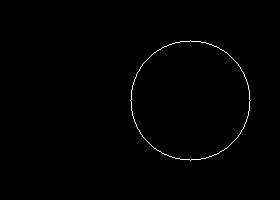

In [ ]:
# Initialize mask
mask = np.zeros_like(img)
mask = cv2.circle(mask, (190, height // 2), 60, 255, 1)
cv2_imshow(mask)


<ipython-input-3-7f043bd16163>:3: RuntimeWarning: overflow encountered in scalar subtract
  texture_dist = abs(lbp_texture[lst1[0], lst1[1]] - lbp_texture[lst2[0], lst2[1]])


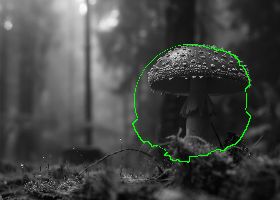

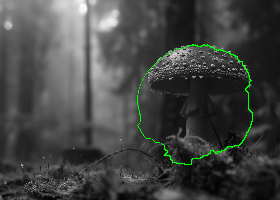

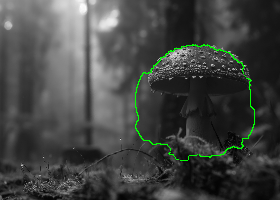

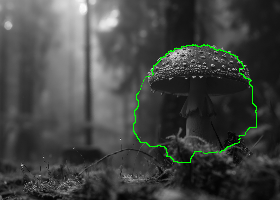

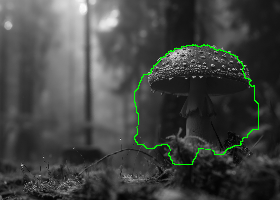

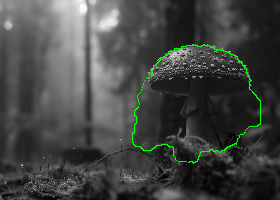

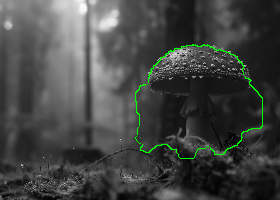

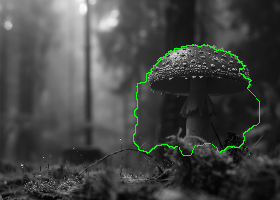

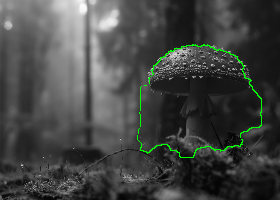

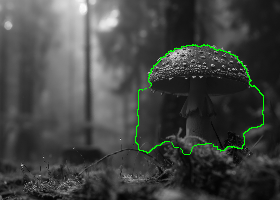

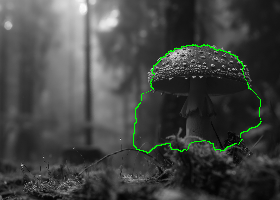

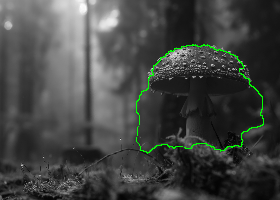

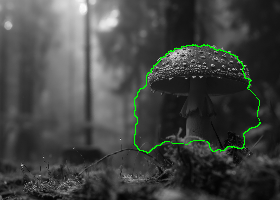

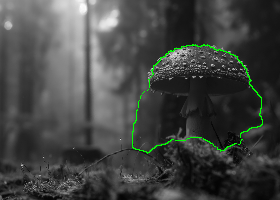

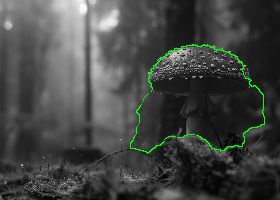

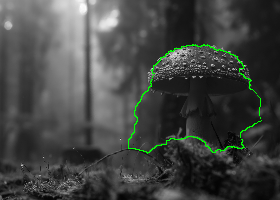

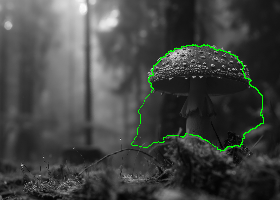

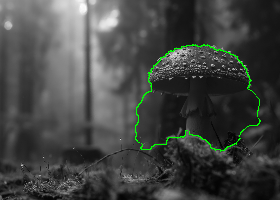

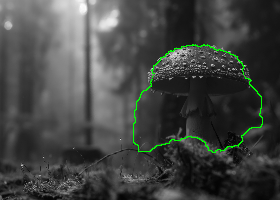

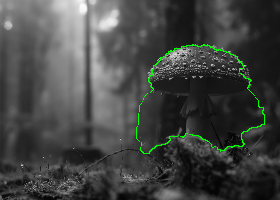

In [ ]:
# Iterative segmentation
for i in range(20):
    allnodes, sink, source = get_coord(mask, 3)
    node_map = {}
    for node in allnodes:
        node_map[str(node)] = (node[0], node[1])

    for node in source:
        node_map[str(node)] = "source"

    for node in sink:
        node_map[str(node)] = "sink"

    G = get_graph(node_map, lbp_texture, texture_weight=0)
    cutset = get_cut(G)
    mask, contour_image = get_nextmask(cutset, node_map)
    cv2_imshow(contour_image)

cv2.waitKey(0)
cv2.destroyAllWindows()
